🎬 Simulation Mode Enabled
Using device: cuda


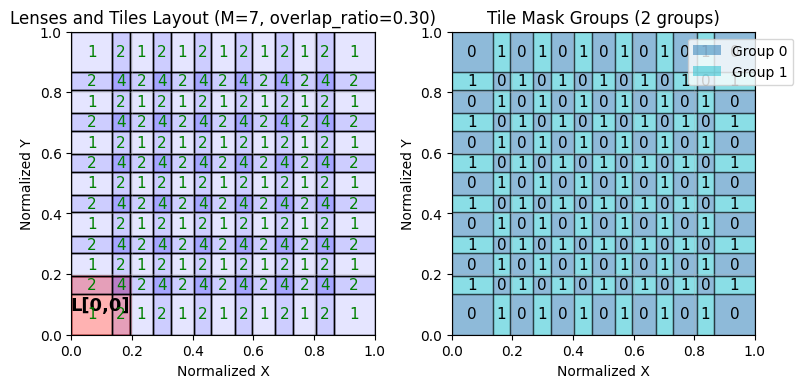


Tile Statistics:
Total tiles: 169
Grid dimensions: 13 x 13
Tiles per group: {0: 85, 1: 84}
Lens contribution distribution: {1: 49, 2: 84, 4: 36}


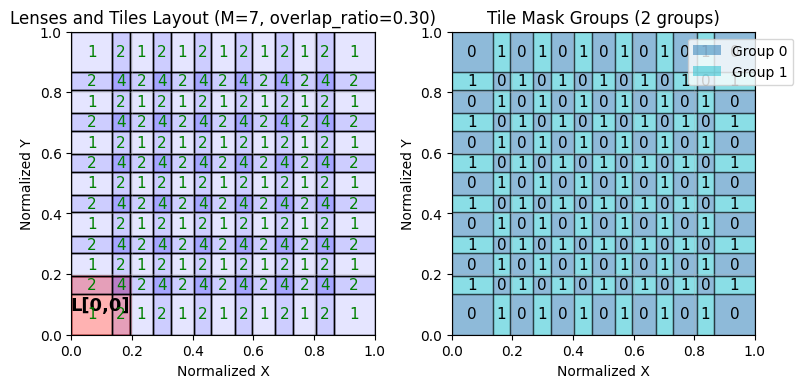


Tile Statistics:
Total tiles: 169
Grid dimensions: 13 x 13
Tiles per group: {0: 85, 1: 84}
Lens contribution distribution: {1: 49, 2: 84, 4: 36}
Starting optimization with 500 iterations...
Iter: 500/500 Loss: 2.0889e+02
Optimization completed. Time elapsed: 30.76 seconds


In [1]:
import config
from optics_utils import process_parameters
from phase_generators import PhaseGenerator
from hardware import SLMManager

slm_manager = SLMManager(sim_mode=True)

# 默认参数字典 from config
test_raw_params = {}
test_raw_params.update(config.COMMON_DEFAULTS)
test_raw_params.update(config.OPTIMIZED_DEFAULTS)
test_raw_params.update(config.INTERNAL)

# 添加测试需要的基本信息 (这些信息之前GUI提供)
test_raw_params['shape'] = slm_manager.shape
test_raw_params['N'] = 980 # ROI尺寸

# 调用参数处理函数
final_params = process_parameters(test_raw_params)

# Optimization init
Optimizer = PhaseGenerator(final_params) 

# Run Optimize
Optimizer.generate(upsampling=2.0)

# Optimizer.generate(mode='fresnel')


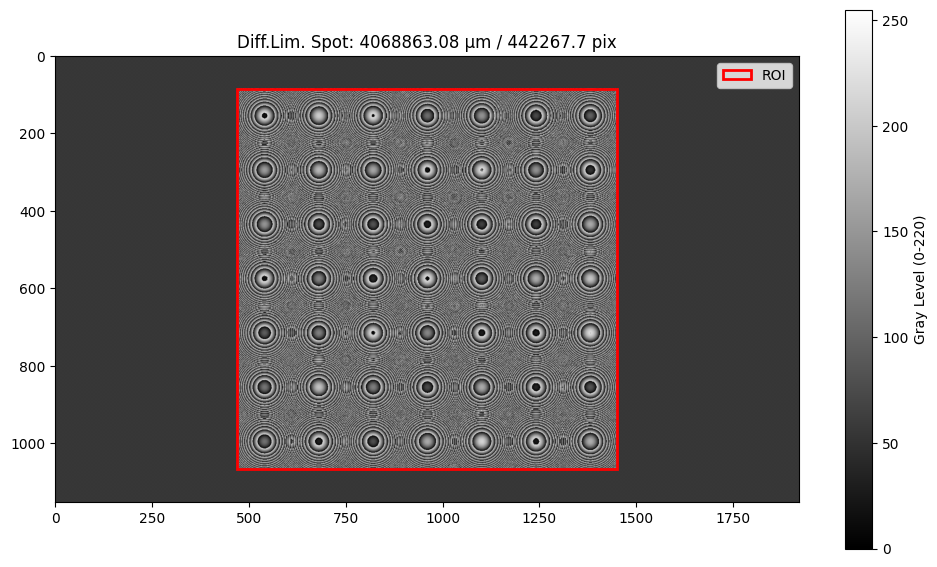

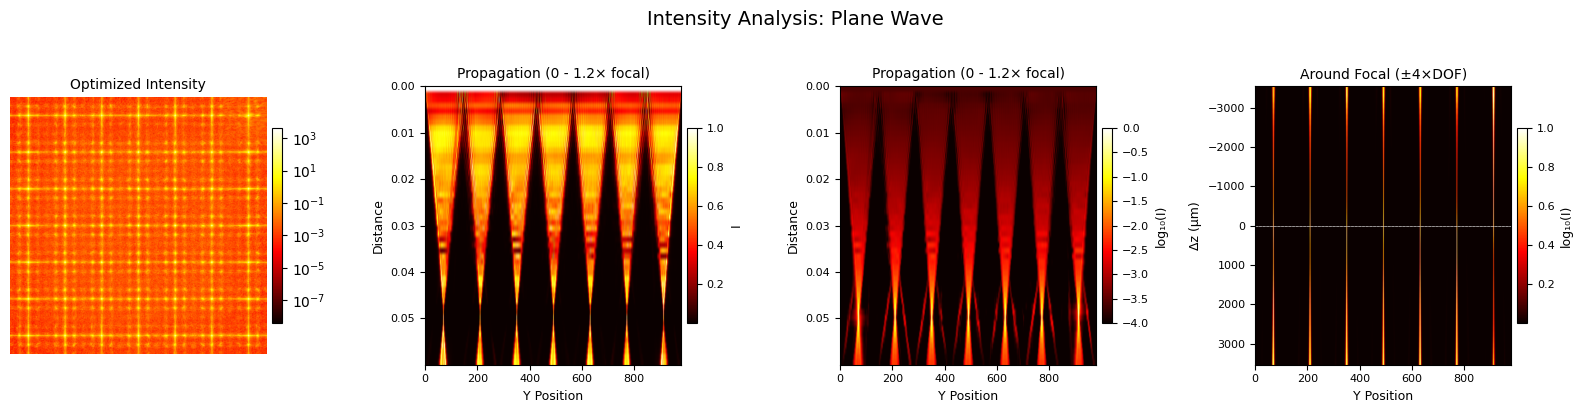

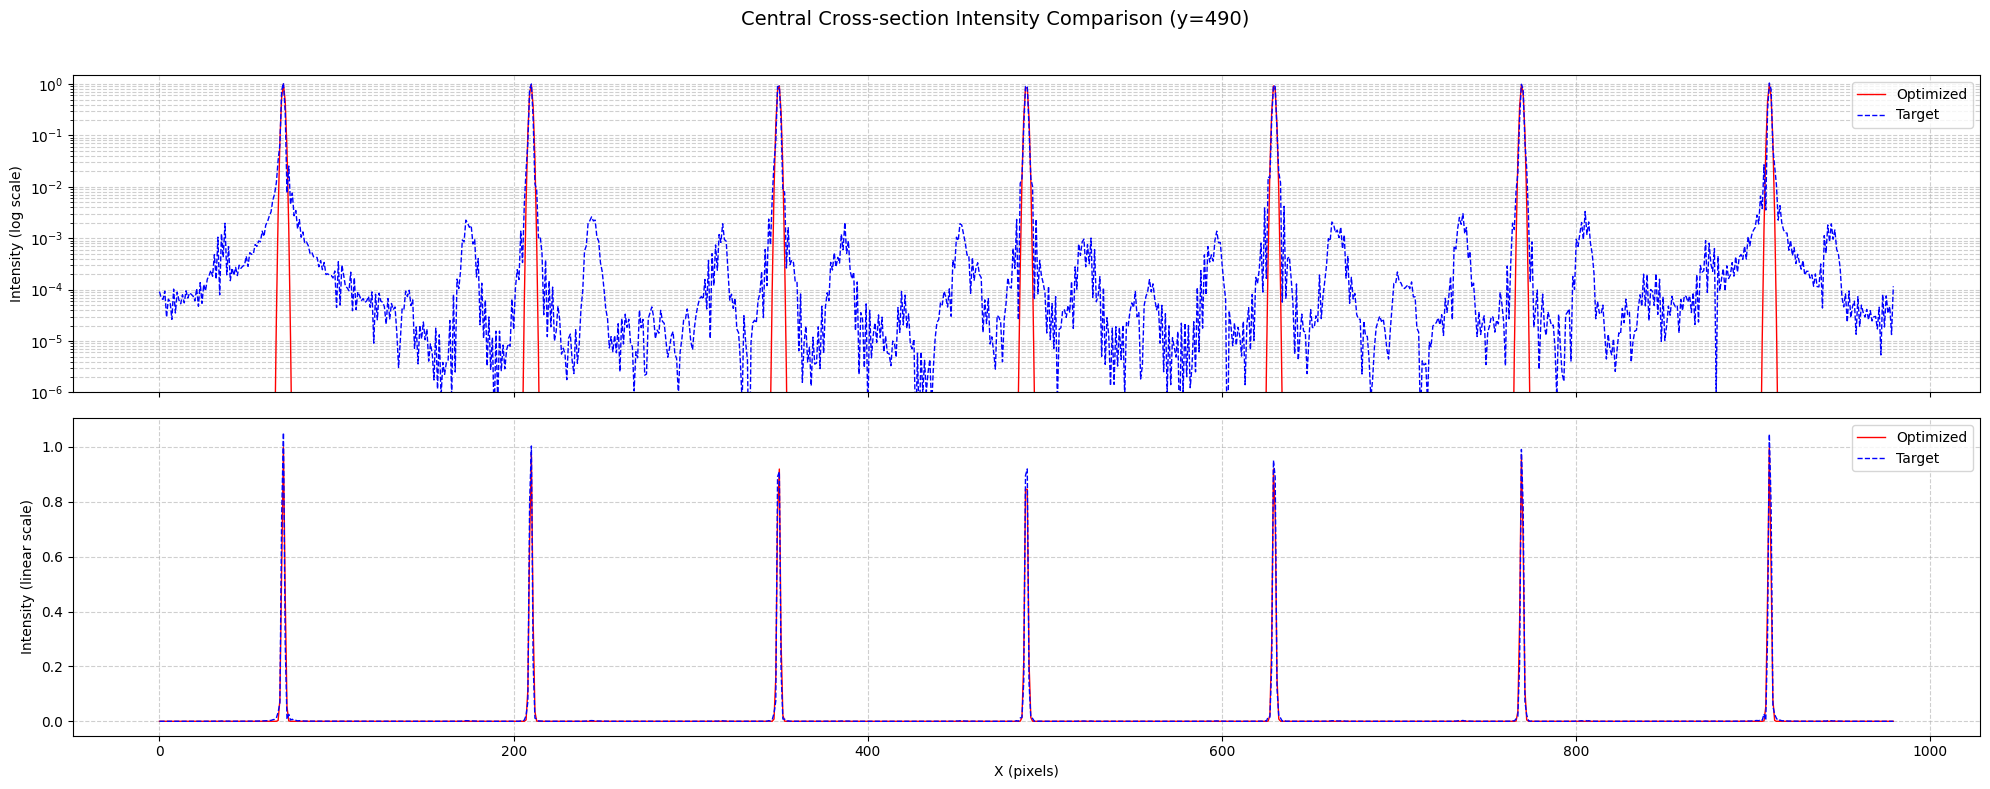

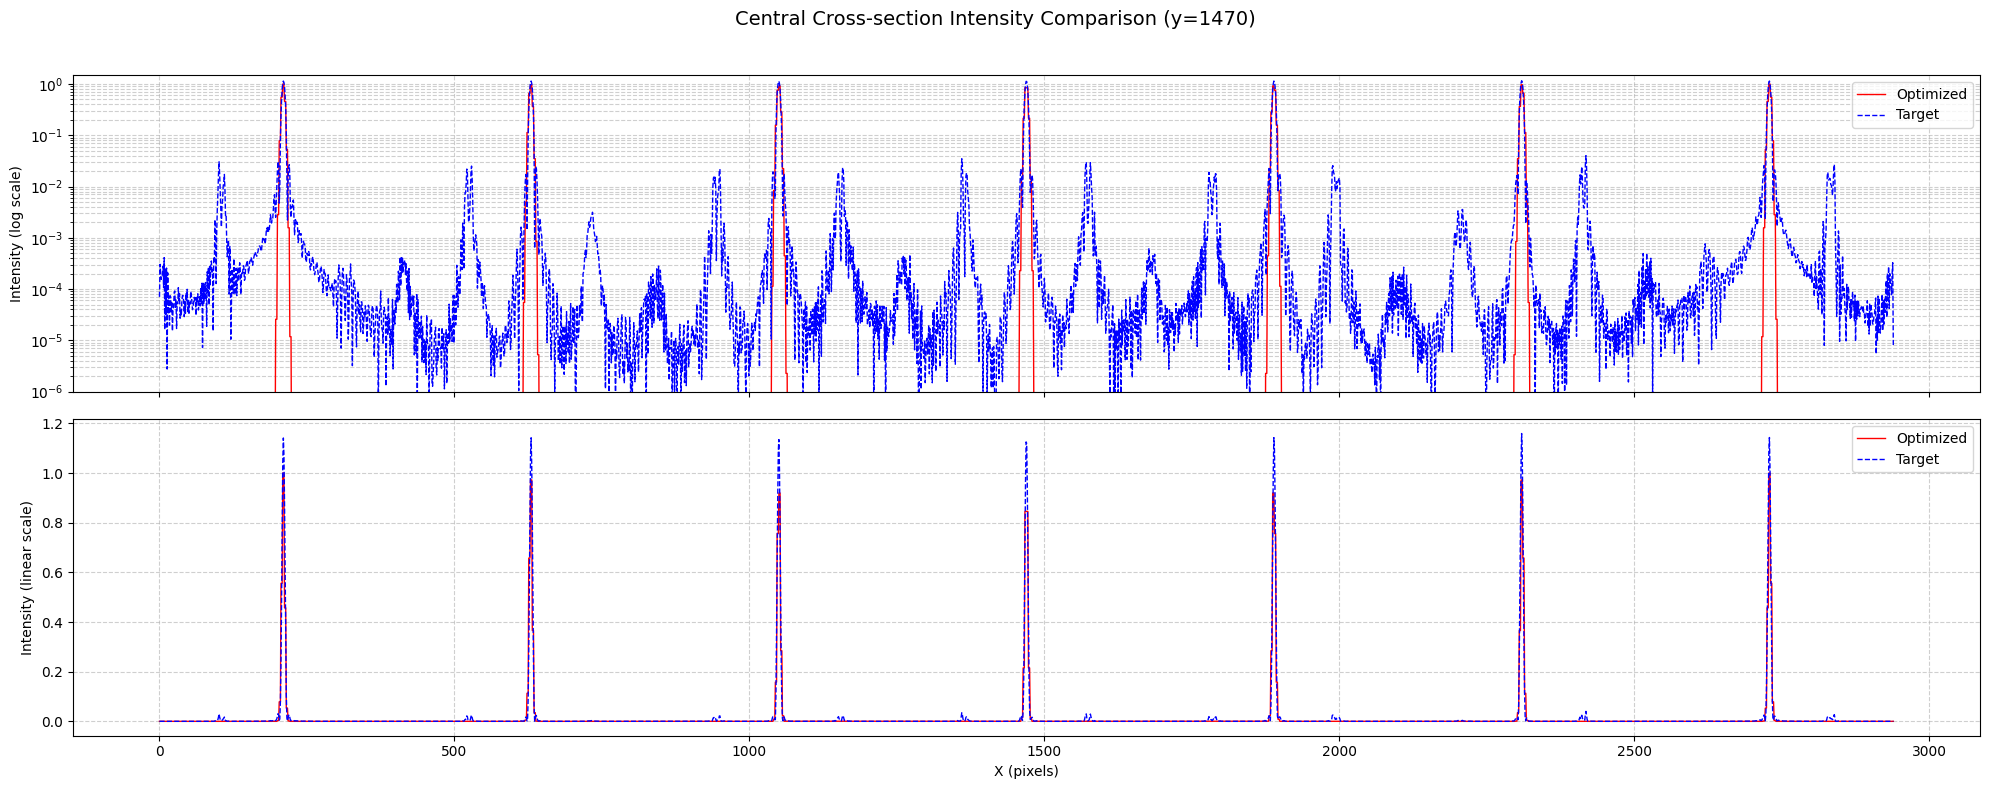

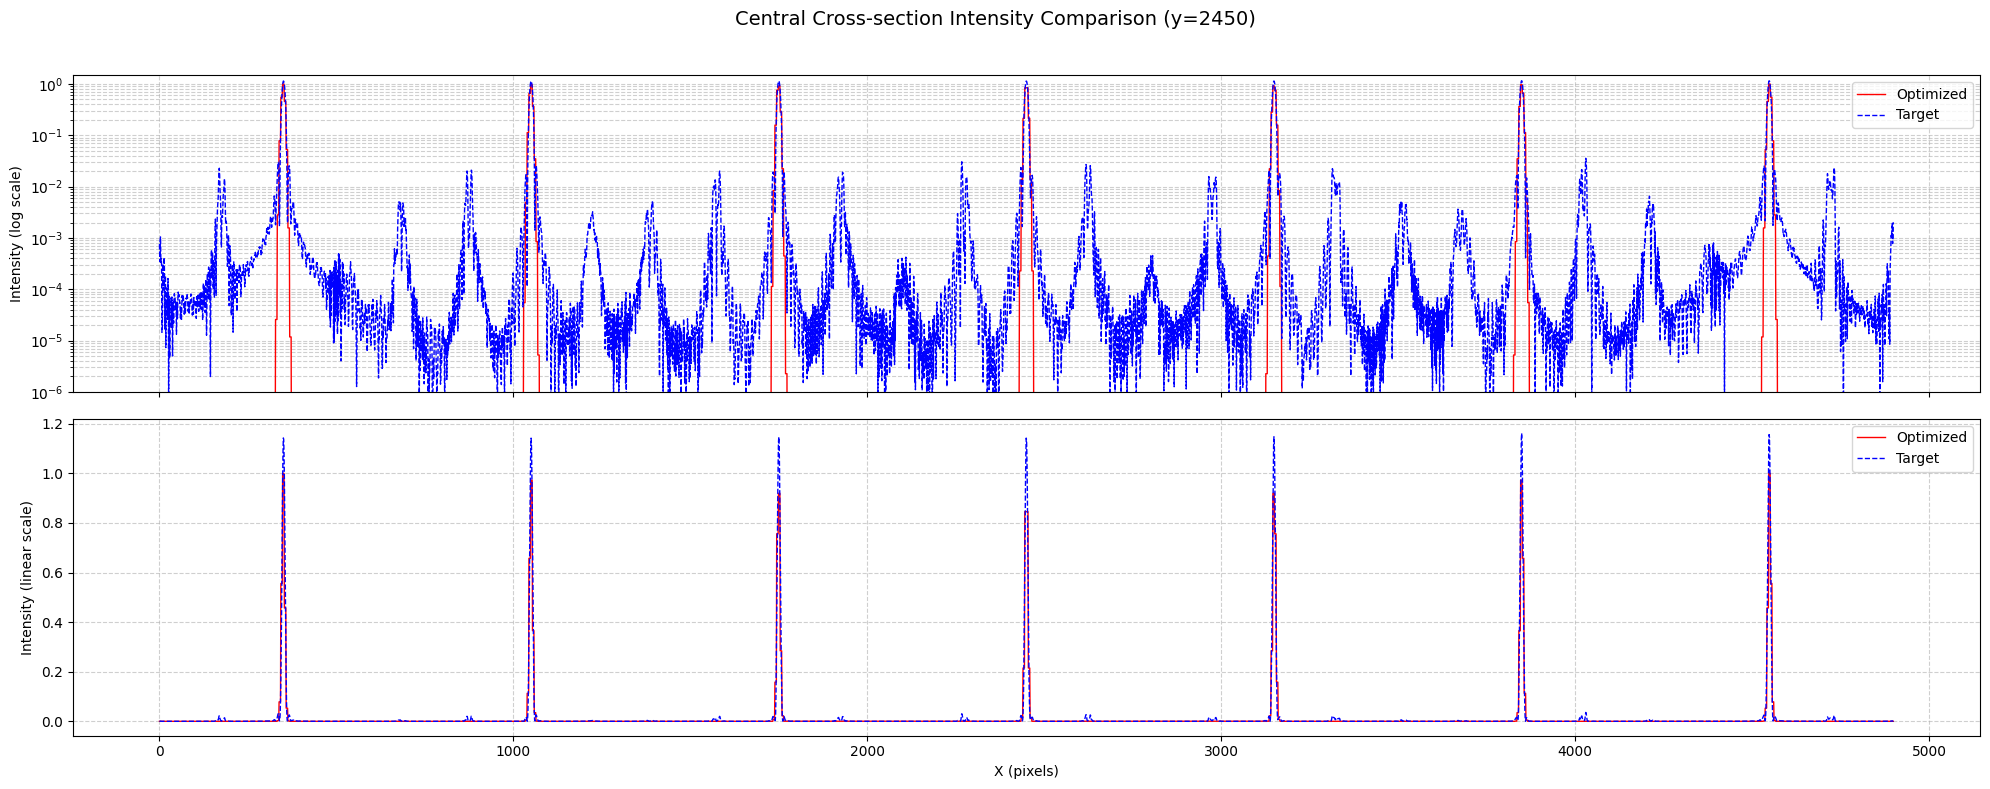

In [2]:
from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
# 可视化
plot_phase(Optimizer)
plot_2d_comparisons(Optimizer)
plot_cross_sections(Optimizer,upsampling=1.0)
plot_cross_sections(Optimizer,upsampling=3)
plot_cross_sections(Optimizer,upsampling=5)


Encircled energy radius used for calculation: 2.03 pixels


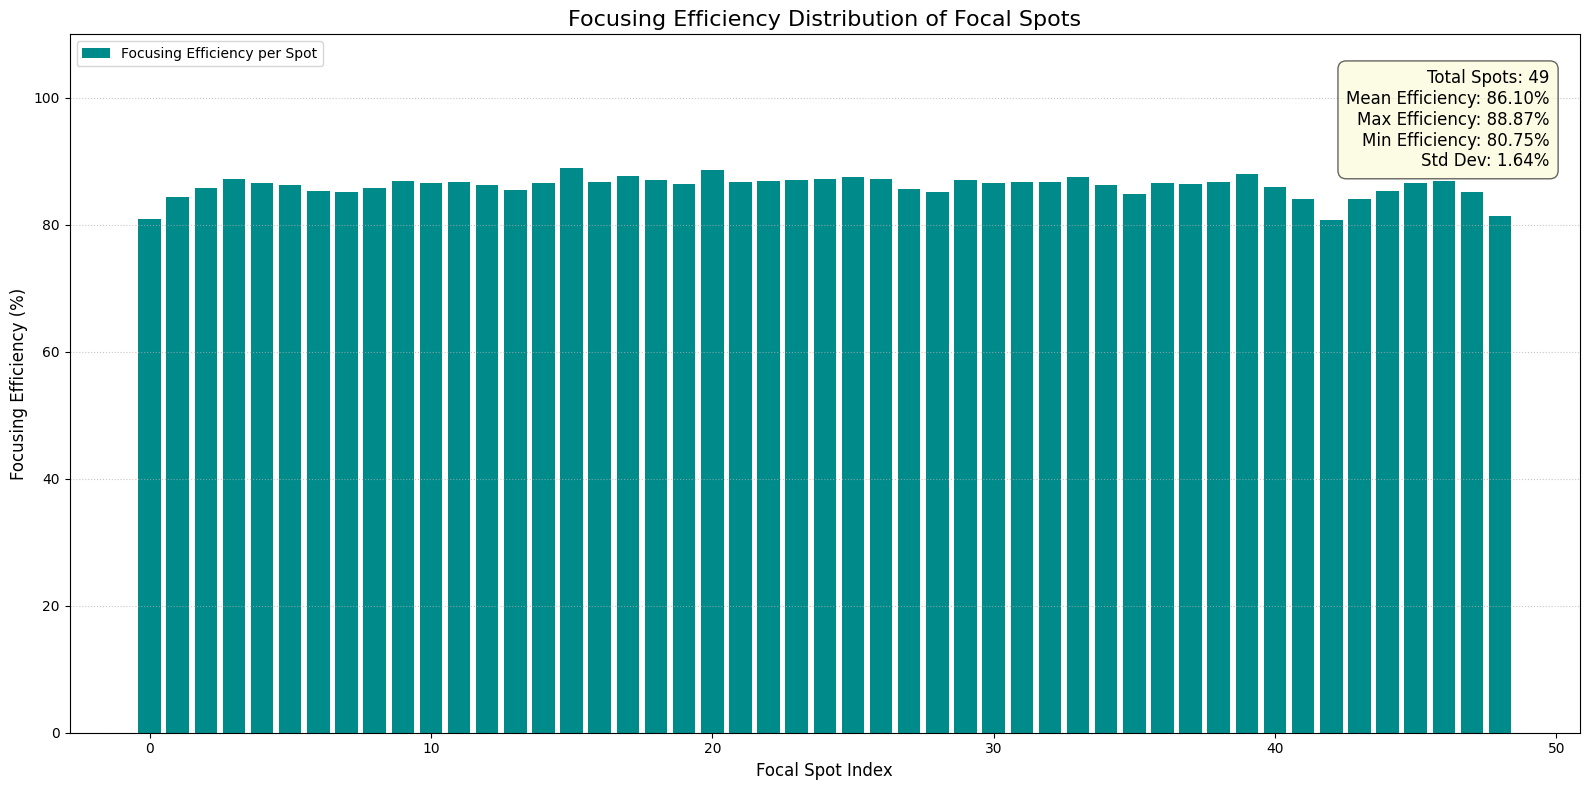

Encircled energy radius used for calculation: 6.10 pixels


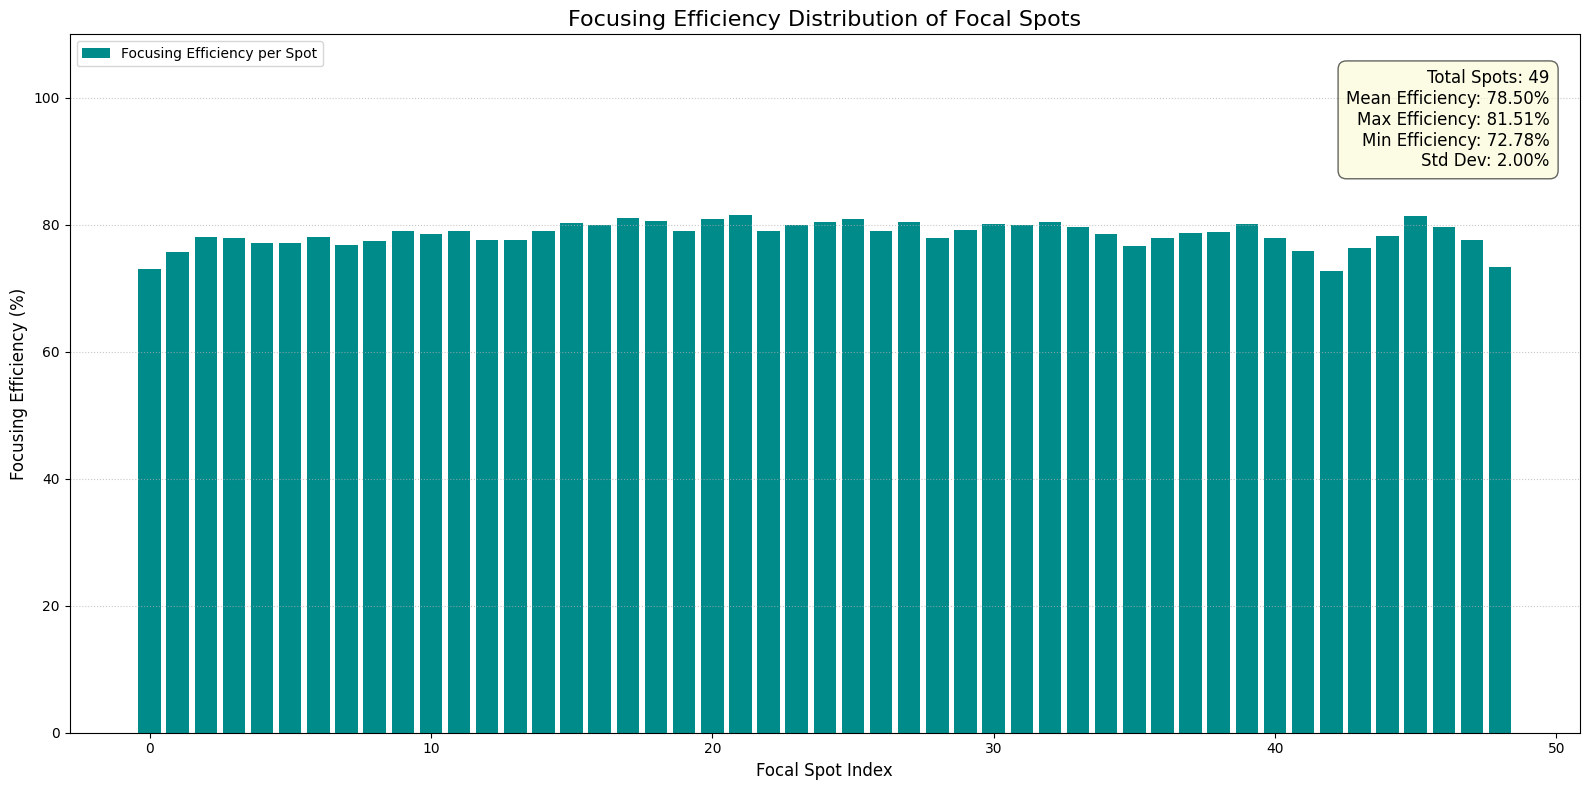

Encircled energy radius used for calculation: 10.17 pixels


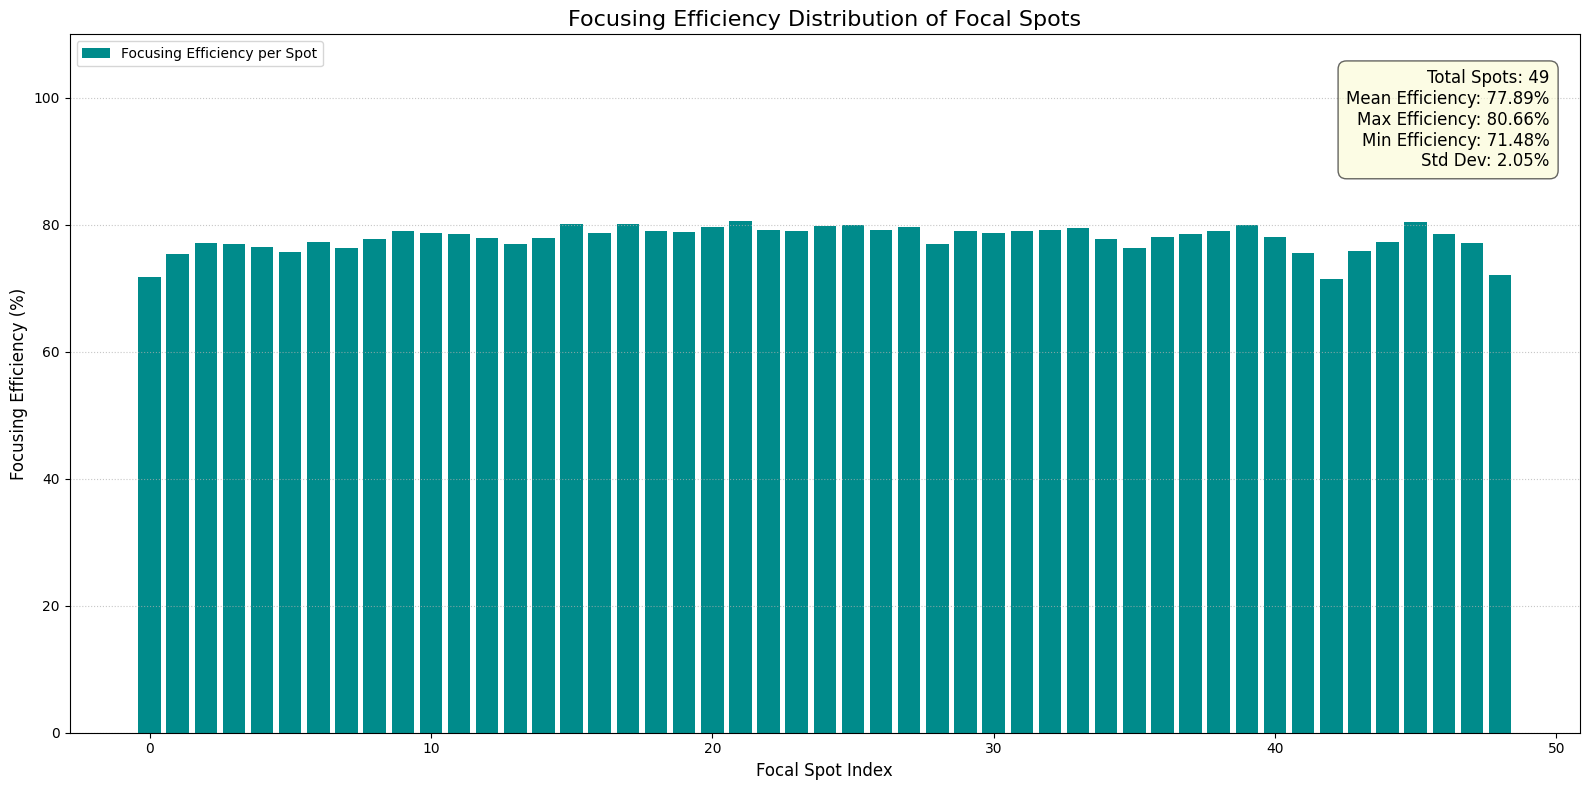

In [3]:
plot_energy_distribution(Optimizer,upsampling=1)
plot_energy_distribution(Optimizer,upsampling=3)
plot_energy_distribution(Optimizer,upsampling=5)